In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

In [5]:
def plot_area_confusion_matrix(truth_shp_path, pred_shp_path, study_area_shp_path, plot_title, out_name):
    """
    Calculates and plots an area-based confusion matrix for overlapping vs non-overlapping shapefiles.
    
    Parameters:
    - truth_shp_path: Path to the ground truth shapefile (polygons)
    - pred_shp_path: Path to the predicted shapefile (polygons)
    - study_area_shp_path: Optional path to a study area/mask shapefile. 
                           If None, uses the bounding box of both shapefiles combined.
    """
    print("Loading shapefiles...")
    gdf_truth = gpd.read_file(truth_shp_path)
    gdf_pred = gpd.read_file(pred_shp_path)
    
    # 1. Ensure matching CRS (Coordinate Reference System)
    if gdf_truth.crs != gdf_pred.crs:
        print(f"Reprojecting predictions to {gdf_truth.crs}...")
        gdf_pred = gdf_pred.to_crs(gdf_truth.crs)
        
    # Warn if using a geographic CRS (like WGS84 / EPSG:4326) instead of projected
    if gdf_truth.crs and gdf_truth.crs.is_geographic:
        print("WARNING: Using a geographic CRS (degrees). Area calculations will be in square degrees. "
              "Consider reprojecting to a local projected CRS (meters) for accurate physical areas.")

    # 2. Merge all geometries into single unified multipolygons
    print("Dissolving geometries...")
    truth_geom = gdf_truth.unary_union
    pred_geom = gdf_pred.unary_union

    # 3. Define the study area (Background)
    if study_area_shp_path:
        gdf_study = gpd.read_file(study_area_shp_path).to_crs(gdf_truth.crs)
        study_geom = gdf_study.unary_union
    else:
        # Fallback: Use the rectangular bounding box of both shapefiles combined
        study_geom = truth_geom.union(pred_geom).envelope

    # 4. Perform spatial operations to calculate areas
    print("Calculating spatial overlaps (areas)...")
    
    # True Positive (Overlap)
    tp_area = truth_geom.intersection(pred_geom).area
    
    # False Negative (Truth but no Prediction)
    fn_area = truth_geom.difference(pred_geom).area
    
    # False Positive (Prediction but no Truth)
    fp_area = pred_geom.difference(truth_geom).area
    
    # True Negative (Inside study area, but neither truth nor prediction)
    union_geom = truth_geom.union(pred_geom)
    tn_area = study_geom.difference(union_geom).area

    # 5. Format into a 2x2 Confusion Matrix array
    # Layout:
    # [[ TN , FP ],
    #  [ FN , TP ]]
    cm_area = np.array([
        [tn_area, fp_area],
        [fn_area, tp_area]
    ])
    tot_area = tn_area + fp_area + fn_area + tp_area
    #print(cm_area)

    # 6. Plotting
    plt.figure(figsize=(8, 6))
    
    # Define labels
    class_names = ['Unflooded (0)', 'Flooded (1)']
    
    # Create heatmap (using formatting for floats since areas can be decimals)
    ax = sns.heatmap(cm_area, annot=True, fmt='.2f', cmap='Blues', cbar=True,
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Area ($m^2$)'},
                annot_kws={"size": 16, "weight": "bold"})
    
    plt.title('Flood Area Confusion Matrix\n'+plot_title, fontsize=16, pad=15)
    plt.ylabel('Am. Samoa Sea Level Rise Viewer', fontsize=14, fontweight='bold')
    plt.xlabel('Umbra Detected', fontsize=14, fontweight='bold')

    plt.xticks(fontsize=14) # Change '14' to your desired size
    plt.yticks(fontsize=14)#, rotation=0) # Keep rotation=0 so y-labels stay horizontal

    # 2. Get the colorbar object from the heatmap
    cbar = ax.collections[0].colorbar
    
    # 3. Set the colorbar label and increase its font size
    cbar.set_label('Area ($m^2$)', size=16)#, weight='bold')
    
    # OPTIONAL: Increase the font size of the numbers (ticks) on the colorbar
    cbar.ax.tick_params(labelsize=12)

    # Add textual interpretation below the plot
    textstr = (f"Flooded Overlap: {tp_area/tot_area*100:.2f}%\n"
               f"Umbra Flooded, AS SLR Unflooded: {fp_area/tot_area*100:.2f}%\n"
               f"Umbra Unflooded, AS SLR Flooded: {fn_area/tot_area*100:.2f}%\n"
               f"Unflooded Overlap: {tn_area/tot_area*100:.2f}%")
    plt.figtext(0.5, -0.1, textstr, wrap=True, horizontalalignment='center', fontsize=11)
    
    plt.tight_layout()

    plt.savefig(out_name, dpi=300, bbox_inches='tight')
    
    plt.show()

Loading shapefiles...
Reprojecting predictions to EPSG:6636...
Dissolving geometries...
Calculating spatial overlaps (areas)...


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  truth_geom = gdf_truth.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pred_geom = gdf_pred.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_geom = gdf_study.unary_union


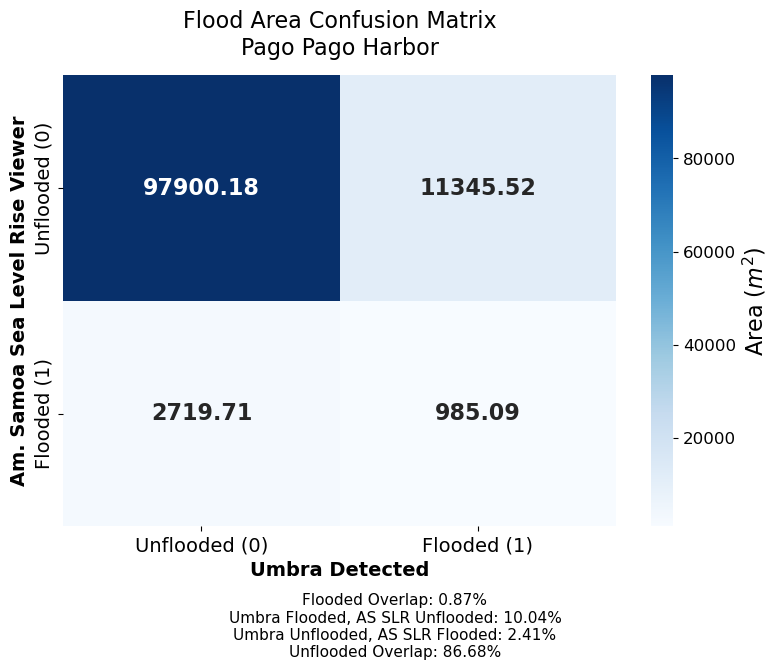

In [6]:
GROUND_TRUTH_SHP = "/Users/sahuang/Documents/DATA/am_samoa/SLR_Viewer/Tutuila_subset_larger/1_foot_no_water.shp"
PREDICTED_SHP = "/Users/sahuang/Documents/DATA/umbra/pago_pago/Pago Pago flood maps/flood_exclude_water_lt_4m.shp"
STUDY_AREA_SHP = "/Users/sahuang/Documents/DATA/am_samoa/AmericanSamoa_3DEP_DEM_10m/pago/USGS_13_s14w171_20130911_lt_4m.shp"

plot_title = 'Pago Pago Harbor'
out_name = '/Users/sahuang/Documents/Manuscripts/2026-Umbra/R1/Figures/FIG_confusion_matrix_w_text_harbor.png'
plot_area_confusion_matrix(GROUND_TRUTH_SHP, PREDICTED_SHP, STUDY_AREA_SHP, plot_title, out_name)

Loading shapefiles...
Reprojecting predictions to EPSG:6636...
Dissolving geometries...


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  truth_geom = gdf_truth.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pred_geom = gdf_pred.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_geom = gdf_study.unary_union


Calculating spatial overlaps (areas)...


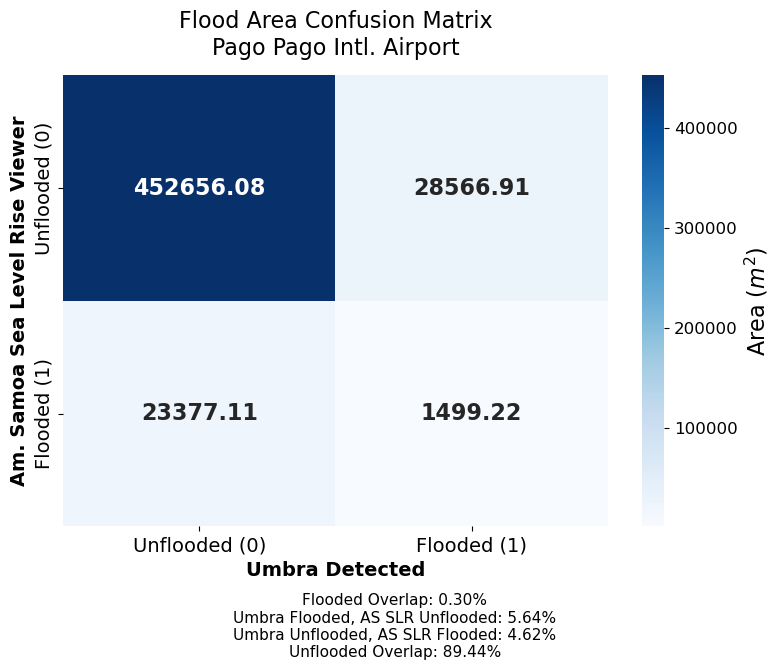

In [7]:
GROUND_TRUTH_SHP = "/Users/sahuang/Documents/DATA/am_samoa/SLR_Viewer/Airport_subet/1_foot_no_water.shp"

PREDICTED_SHP = "/Users/sahuang/Documents/DATA/umbra/tafuna/Tafuna flood maps/flood_exclude_water.shp"

# Optional: A shapefile defining the exact boundary of your analysis
STUDY_AREA_SHP = "/Users/sahuang/Documents/DATA/am_samoa/Landcover/tafuna_ccap_ocean_mask_crop.shp"

plot_title = 'Pago Pago Intl. Airport'
out_name = '/Users/sahuang/Documents/Manuscripts/2026-Umbra/R1/Figures/FIG_confusion_matrix_w_text_airport.png'
plot_area_confusion_matrix(GROUND_TRUTH_SHP, PREDICTED_SHP, STUDY_AREA_SHP, plot_title, out_name)

Loading shapefiles...
Reprojecting predictions to EPSG:6636...
Dissolving geometries...
Calculating spatial overlaps (areas)...


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  truth_geom = gdf_truth.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pred_geom = gdf_pred.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_geom = gdf_study.unary_union


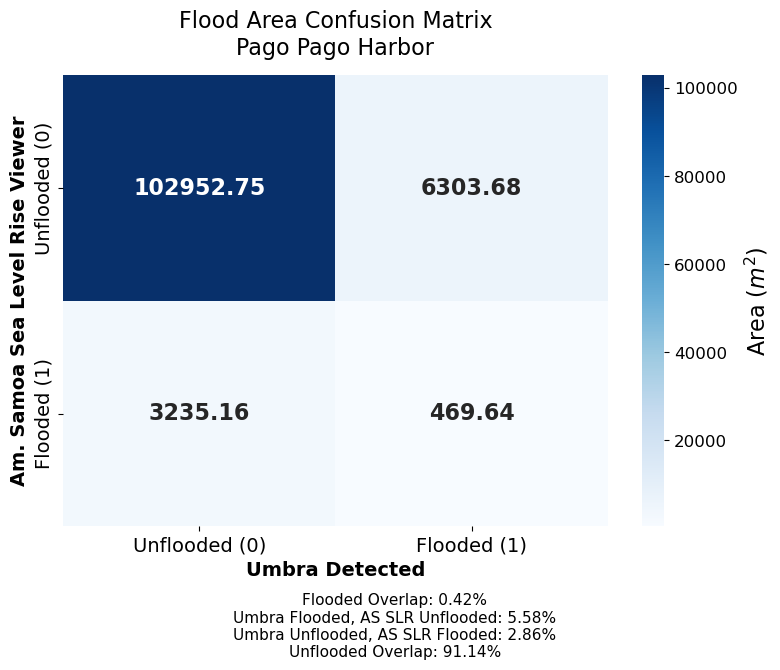

In [8]:
GROUND_TRUTH_SHP = "/Users/sahuang/Documents/DATA/am_samoa/SLR_Viewer/Tutuila_subset_larger/1_foot_no_water.shp"
PREDICTED_SHP = "/Users/sahuang/Documents/DATA/umbra/AS_Water_Masks/Pago/Pago_flood_map.shp"
STUDY_AREA_SHP = "/Users/sahuang/Documents/DATA/am_samoa/AmericanSamoa_3DEP_DEM_10m/pago/USGS_13_s14w171_20130911_lt_4m.shp"

plot_title = 'Pago Pago Harbor'
out_name = '/Users/sahuang/Documents/Manuscripts/2026-Umbra/R1/Figures/FIG_confusion_matrix_w_text_harbor_auto.png'
plot_area_confusion_matrix(GROUND_TRUTH_SHP, PREDICTED_SHP, STUDY_AREA_SHP, plot_title, out_name)

Loading shapefiles...
Reprojecting predictions to EPSG:6636...
Dissolving geometries...


/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:27: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  truth_geom = gdf_truth.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:28: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  pred_geom = gdf_pred.unary_union
/var/folders/xg/d7l0rjhd61v1zgdny2854dq8w3qvvz/T/ipykernel_58174/3548968362.py:33: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  study_geom = gdf_study.unary_union


Calculating spatial overlaps (areas)...


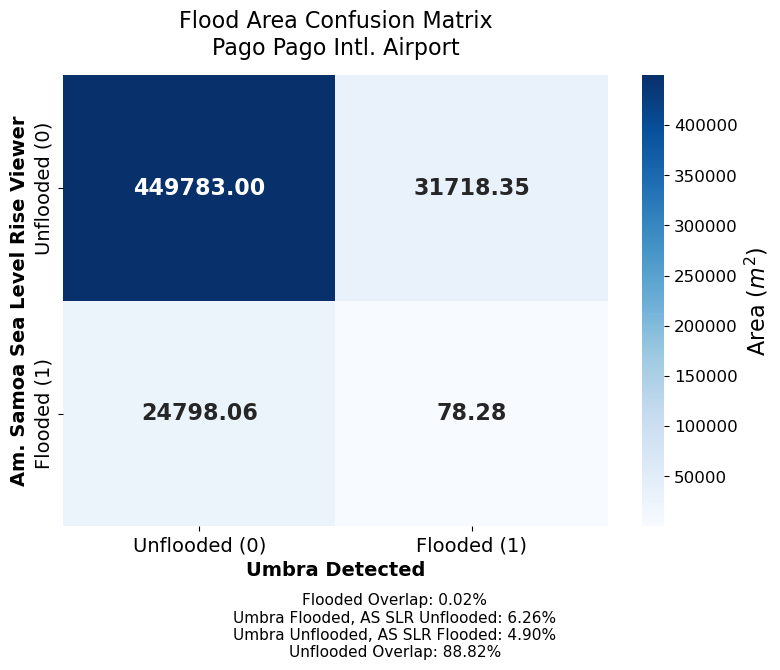

In [9]:
GROUND_TRUTH_SHP = "/Users/sahuang/Documents/DATA/am_samoa/SLR_Viewer/Airport_subet/1_foot_no_water.shp"
PREDICTED_SHP = "/Users/sahuang/Documents/DATA/umbra/AS_Water_Masks/Tafuna/Tafuna_flood_map.shp"

# Optional: A shapefile defining the exact boundary of your analysis
STUDY_AREA_SHP = "/Users/sahuang/Documents/DATA/am_samoa/Landcover/tafuna_ccap_ocean_mask_crop.shp"

plot_title = 'Pago Pago Intl. Airport'
out_name = '/Users/sahuang/Documents/Manuscripts/2026-Umbra/R1/Figures/FIG_confusion_matrix_w_text_airport_auto.png'
plot_area_confusion_matrix(GROUND_TRUTH_SHP, PREDICTED_SHP, STUDY_AREA_SHP, plot_title, out_name)